In [1]:
import pandas as pd

data = {
    "Customers": ["A","B","C","D","E","F","G","H","I","J","K","L"],
    "Annual_Income": [25,28,30,32,45,48,50,52,70,75,78,80],
    "Spending_Score": [20,25,22,28,50,55,52,58,80,85,82,88]
}

df= pd.DataFrame(data)
print (df)

   Customers  Annual_Income  Spending_Score
0          A             25              20
1          B             28              25
2          C             30              22
3          D             32              28
4          E             45              50
5          F             48              55
6          G             50              52
7          H             52              58
8          I             70              80
9          J             75              85
10         K             78              82
11         L             80              88


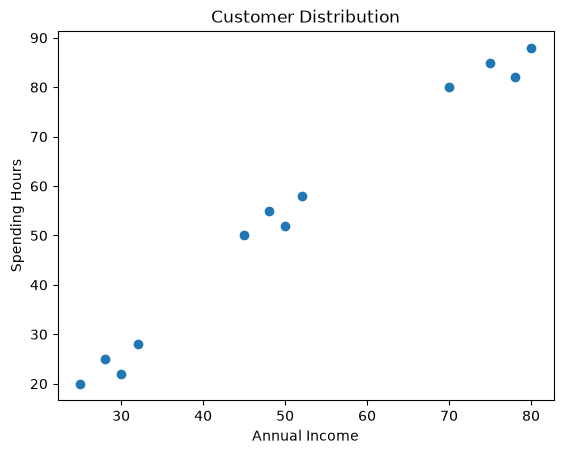

In [4]:
import matplotlib.pyplot as plt
plt.scatter(df["Annual_Income"], df["Spending_Score"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Hours")
plt.title("Customer Distribution")
plt.show()


   Customers  Annual_Income  Spending_Score  Cluster
0          A             25              20        2
1          B             28              25        2
2          C             30              22        2
3          D             32              28        2
4          E             45              50        0
5          F             48              55        0
6          G             50              52        0
7          H             52              58        0
8          I             70              80        1
9          J             75              85        1
10         K             78              82        1
11         L             80              88        1


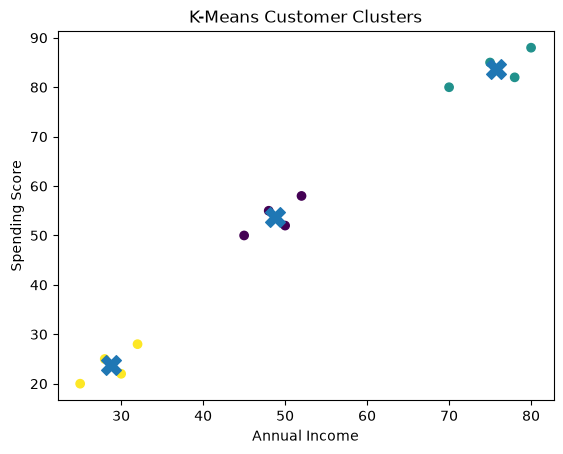

In [12]:
from sklearn.cluster import KMeans
X= df[["Annual_Income","Spending_Score"]]
kmeans=KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)  #training model
df["Cluster"]=kmeans.labels_
print(df)

plt.scatter(df["Annual_Income"], df["Spending_Score"], c=df["Cluster"])

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:,1], marker="X", s=200)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Customer Clusters")
plt.show()

[11871.166666666666, 2820.5, 220.5, 157.66666666666666, 119.5, 83.66666666666666]


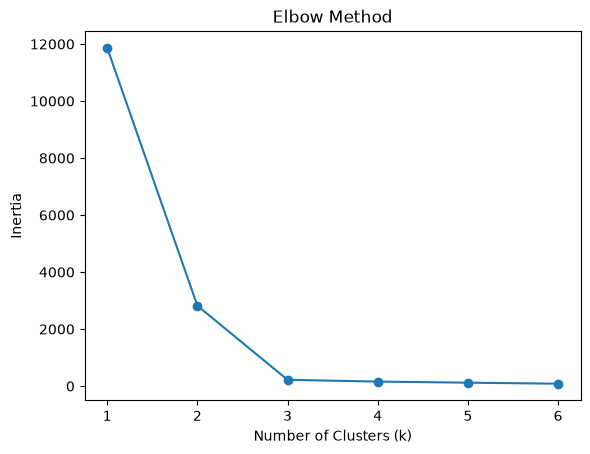

         Annual_Income  Spending_Score
Cluster                               
0                48.75           53.75
1                75.75           83.75
2                28.75           23.75
Cluster
2    4
0    4
1    4
Name: count, dtype: int64


In [18]:
#inertia
inertia=[]
for k in range(1,7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)

    inertia.append(model.inertia_)

print(inertia)

#plot inertia
plt.plot(range(1,7), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

summary = df.groupby("Cluster")[[
    "Annual_Income",
    "Spending_Score"
]].mean()

print(summary)


# --------------------------------------------------
# 13. NUMBER OF CUSTOMERS PER CLUSTER
# --------------------------------------------------

print(df["Cluster"].value_counts())

  Customer  Annual_Income  Spending_Score
0        A             25              20
1        B             28              25
2        C             30              22
3        D             32              28
4        E             45              50
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer        12 non-null     str  
 1   Annual_Income   12 non-null     int64
 2   Spending_Score  12 non-null     int64
dtypes: int64(2), str(1)
memory usage: 420.0 bytes
None
       Annual_Income  Spending_Score
count      12.000000        12.00000
mean       51.083333        53.75000
std        20.362436        25.77922
min        25.000000        20.00000
25%        31.500000        27.25000
50%        49.000000        53.50000
75%        71.250000        80.50000
max        80.000000        88.00000


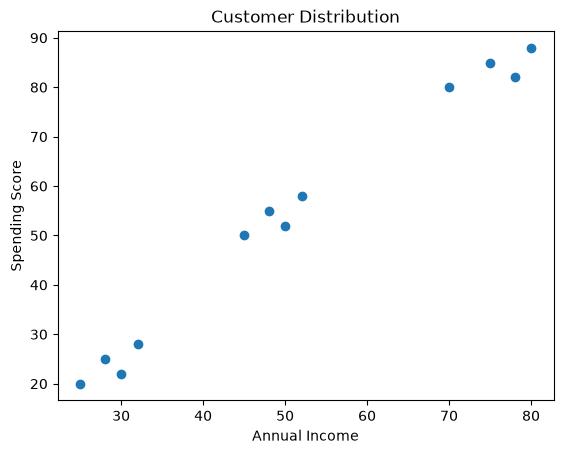

   Customer  Annual_Income  Spending_Score  Cluster
0         A             25              20        2
1         B             28              25        2
2         C             30              22        2
3         D             32              28        2
4         E             45              50        0
5         F             48              55        0
6         G             50              52        0
7         H             52              58        0
8         I             70              80        1
9         J             75              85        1
10        K             78              82        1
11        L             80              88        1
[[48.75 53.75]
 [75.75 83.75]
 [28.75 23.75]]


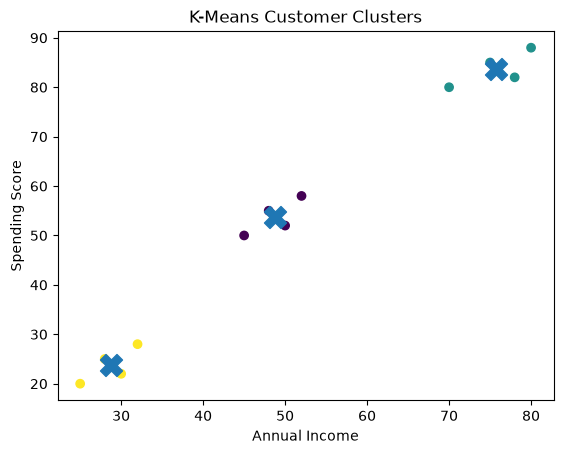

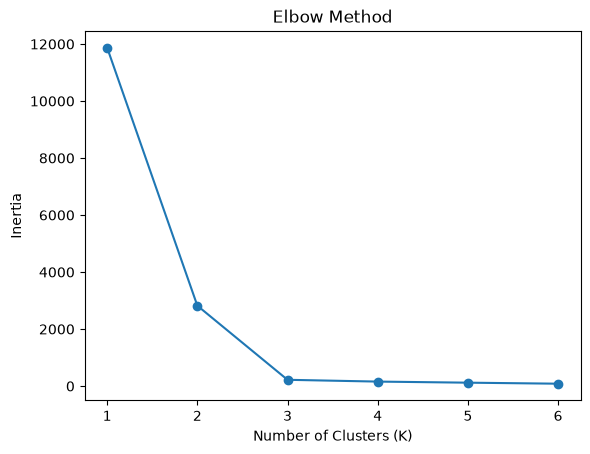

         Annual_Income  Spending_Score
Cluster                               
0                48.75           53.75
1                75.75           83.75
2                28.75           23.75
Cluster
2    4
0    4
1    4
Name: count, dtype: int64


In [16]:
#Code done by Rishi sir


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans


# --------------------------------------------------
# 1. CREATE DATAFRAME
# --------------------------------------------------

data = {
    "Customer": [
        "A", "B", "C", "D",
        "E", "F", "G", "H",
        "I", "J", "K", "L"
    ],
    "Annual_Income": [
        25, 28, 30, 32,
        45, 48, 50, 52,
        70, 75, 78, 80
    ],
    "Spending_Score": [
        20, 25, 22, 28,
        50, 55, 52, 58,
        80, 85, 82, 88
    ]
}

df = pd.DataFrame(data)


# --------------------------------------------------
# 2. EXPLORE
# --------------------------------------------------

print(df.head())

print(df.info())

print(df.describe())


# --------------------------------------------------
# 3. VISUALIZE ORIGINAL DATA
# --------------------------------------------------

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")

plt.show()


# --------------------------------------------------
# 4. SELECT FEATURES
# --------------------------------------------------

X = df[
    [
        "Annual_Income",
        "Spending_Score"
    ]
]


# --------------------------------------------------
# 5. CREATE K-MEANS
# --------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)


# --------------------------------------------------
# 6. TRAIN + PREDICT
# --------------------------------------------------

df["Cluster"] = kmeans.fit_predict(X)


# --------------------------------------------------
# 7. DISPLAY CLUSTERS
# --------------------------------------------------

print(df)


# --------------------------------------------------
# 8. DISPLAY CENTROIDS
# --------------------------------------------------

print(kmeans.cluster_centers_)


# --------------------------------------------------
# 9. VISUALIZE CLUSTERS
# --------------------------------------------------

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"]
)

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Customer Clusters")

plt.show()


# --------------------------------------------------
# 10. ELBOW METHOD
# --------------------------------------------------

inertia = []

for k in range(1, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(model.inertia_)


# --------------------------------------------------
# 11. ELBOW PLOT
# --------------------------------------------------

plt.plot(
    range(1, 7),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


# --------------------------------------------------
# 12. CLUSTER SUMMARY
# --------------------------------------------------

summary = df.groupby("Cluster")[[
    "Annual_Income",
    "Spending_Score"
]].mean()

print(summary)


# --------------------------------------------------
# 13. NUMBER OF CUSTOMERS PER CLUSTER
# --------------------------------------------------

print(df["Cluster"].value_counts())